In [1]:
# Libraries
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

In [2]:
# TensorFlow / Keras functions
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import Sequential, Input, Model
from tensorflow.keras.layers import Dense, Conv2D, Flatten, MaxPooling2D
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping

In [3]:
#Download and fetch the data using the following Python code (Note: We will use faces.images for X).

# Load the data
from sklearn.datasets import fetch_olivetti_faces
faces = fetch_olivetti_faces()
X = faces.images
y = faces.target.reshape(-1, 1)

downloading Olivetti faces from https://ndownloader.figshare.com/files/5976027 to C:\Users\HK\scikit_learn_data


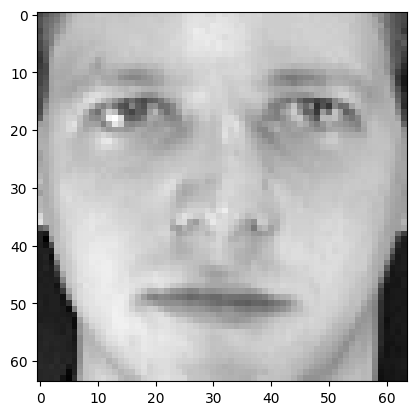

In [4]:
# Selecting an image
image = X[0]  # choose the first image in the dataset

# Display the image
plt.imshow(image, cmap=plt.cm.gray)
plt.show()

In [5]:
# Creating the training and testing sets

X_train_list = []
X_test_list = []
y_train_list = []
y_test_list = []

y_flat = faces.target  # shape (400,)

for person_id in np.unique(y_flat):
    # Get all images for this person
    idx = np.where(y_flat == person_id)[0]
    
    # Split first 5 for training, last 5 for testing
    X_train_list.append(X[idx[:5]])
    X_test_list.append(X[idx[5:]])
    
    y_train_list.append(y_flat[idx[:5]])
    y_test_list.append(y_flat[idx[5:]])

# Combine all persons into final arrays
X_train = np.concatenate(X_train_list)
X_test = np.concatenate(X_test_list)
y_train = np.concatenate(y_train_list)
y_test = np.concatenate(y_test_list)

# Print dimensions
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (200, 64, 64)
X_test shape: (200, 64, 64)
y_train shape: (200,)
y_test shape: (200,)


In [6]:
# Conversion
# Convert labels to one-hot encoded format (40 classes)
y_train_onehot = to_categorical(y_train, num_classes=40)
y_test_onehot = to_categorical(y_test, num_classes=40)

# Print dimensions
print("y_train_onehot shape:", y_train_onehot.shape)
print("y_test_onehot shape:", y_test_onehot.shape)

y_train_onehot shape: (200, 40)
y_test_onehot shape: (200, 40)


In [7]:
#Reshape the data to fit the input shape of a CNN (200, 64, 64, 1)
# Reshape images to add channel dimension (1 for grayscale)
X_train_reshaped = X_train.reshape(X_train.shape[0], 64, 64, 1)
X_test_reshaped = X_test.reshape(X_test.shape[0], 64, 64, 1)

# Print new shapes
print("X_train_reshaped shape:", X_train_reshaped.shape)
print("X_test_reshaped shape:", X_test_reshaped.shape)

X_train_reshaped shape: (200, 64, 64, 1)
X_test_reshaped shape: (200, 64, 64, 1)
